DETECTION OF IT SYSTEM BOTTLENECKS USING ML ON SERVER AND NETWORK PERFORMANCE LOGS

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


df_server = pd.read_csv("/content/drive/MyDrive/ML_Project/data/system.csv")
df_net = pd.read_csv("/content/drive/MyDrive/ML_Project/data/network.csv")


In [3]:
df_server

,timestamp,load-1m,load-5m,load-15m,sys-mem-swap-total,sys-mem-swap-free,sys-mem-free,sys-mem-cache,sys-mem-buffered,sys-mem-available,...,sys-thermal,disk-io-time,disk-bytes-read,disk-bytes-written,disk-io-read,disk-io-write,cpu-iowait,cpu-system,cpu-user,server-up
0,0,0.24,0.31,0.29,8259629056,8254619648,141746176,5219205120,1040769024,6802706432,...,1.70,0.0124,0.0,21913.6,0.0,3.25,0.0145,0.0475,0.1815,2
1,30,0.41,0.36,0.30,8259629056,8254619648,143802368,5219807232,1040793600,6805430272,...,0.15,0.0252,0.0,118169.6,0.0,13.40,0.0185,0.0380,0.0375,2
2,60,0.30,0.34,0.30,8259629056,8254619648,132952064,5219676160,1040793600,6794432512,...,1.70,0.0278,0.0,94822.4,0.0,11.40,0.0140,0.0520,0.0645,2
3,90,0.24,0.32,0.29,8259629056,8254619648,134139904,5218275328,1040793600,6794231808,...,1.85,0.0212,0.0,84582.4,0.0,12.80,0.0195,0.0405,0.1635,2
4,120,0.15,0.29,0.28,8259629056,8254619648,130904064,5218996224,1040793600,6791729152,...,1.70,0.0164,0.0,66969.6,0.0,6.30,0.0110,0.0550,0.0695,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86396,2591880,0.31,0.28,0.21,8259629056,8254087168,3130667008,2439143424,1151901696,6996000768,...,1.70,0.0088,0.0,32358.4,0.0,2.60,0.0090,0.0810,0.1095,2
86397,2591910,0.19,0.25,0.20,8259629056,8254087168,3119390720,2439667712,1151901696,6985216000,...,1.60,0.0088,0.0,28057.6,0.0,2.70,0.0140,0.0425,0.0315,2
86398,2591940,0.19,0.24,0.20,8259629056,8254087168,2971799552,2440114176,1151901696,6838116352,...,0.00,0.0170,0.0,90931.2,0.0,9.90,0.0135,0.0430,0.1695,2
86399,2591970,0.18,0.23,0.20,8259629056,8254087168,2964934656,2440081408,1151901696,6831202304,...,0.00,0.0142,0.0,41779.2,0.0,7.30,0.0140,0.0565,0.0525,2


In [4]:
df_net

,resp_pkts,service,orig_ip_bytes,local_resp,missed_bytes,protocol,duration,conn_state,dest_ip,orig_pkts,...,orig_bytes,local_orig,datetime,history,resp_bytes,uid,src_port,ts,src_ip,mitre_attack_tactics
0,2,dns,186,False,0,udp,0.002242,SF,143.88.5.1,2,...,130.0,False,2022-02-10T04:00:00.089Z,Dd,130.0,CwYA8M2mT6ATemGMV5,41058,1.640000e+09,143.88.5.12,Reconnaissance
1,2,dns,186,False,0,udp,0.002242,SF,143.88.5.1,2,...,130.0,False,2022-02-10T04:00:00.089Z,Dd,130.0,CwYA8M2mT6ATemGMV5,41058,1.640000e+09,143.88.5.12,Reconnaissance
2,2,dns,186,False,0,udp,0.002242,SF,143.88.5.1,2,...,130.0,False,2022-02-10T04:00:00.089Z,Dd,130.0,CwYA8M2mT6ATemGMV5,41058,1.640000e+09,143.88.5.12,Reconnaissance
3,2,dns,186,False,0,udp,0.002242,SF,143.88.5.1,2,...,130.0,False,2022-02-10T04:00:00.089Z,Dd,130.0,CwYA8M2mT6ATemGMV5,41058,1.640000e+09,143.88.5.12,Reconnaissance
4,2,dns,186,False,0,udp,0.002242,SF,143.88.5.1,2,...,130.0,False,2022-02-10T04:00:00.089Z,Dd,130.0,CwYA8M2mT6ATemGMV5,41058,1.640000e+09,143.88.5.12,Reconnaissance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000590,5,dns,355,False,0,udp,17.449711,SF,143.88.11.1,5,...,215.0,False,2022-01-09T05:52:17.543Z,Dd,215.0,CH9S6nuDiPCHNRzVc,63048,1.640000e+09,143.88.11.13,none
1000591,5,dns,355,False,0,udp,17.522094,SF,143.88.11.1,5,...,215.0,False,2022-01-14T12:29:24.580Z,Dd,215.0,CtL0NG3OKG5oYIyR07,54691,1.640000e+09,143.88.11.13,none
1000592,5,dns,355,False,0,udp,17.906101,SF,143.88.11.1,5,...,215.0,False,2022-01-14T12:38:59.597Z,Dd,215.0,CSxt2i2gLTxzLhp9p5,49235,1.640000e+09,143.88.11.13,none
1000593,5,dns,355,False,0,udp,18.840472,SF,143.88.11.1,5,...,215.0,False,2022-01-09T04:31:02.659Z,Dd,215.0,CYcXNk16s3h30uIwgk,64872,1.640000e+09,143.88.11.13,none


In [5]:
df_server['timestamp'] = pd.to_datetime(df_server['timestamp'], unit='s')

df_net['datetime'] = pd.to_datetime(df_net['datetime']).dt.tz_localize(None)

In [6]:
df = pd.merge_asof(
    df_server.sort_values('timestamp'),
    df_net.sort_values('datetime'),
    left_on='timestamp',
    right_on='datetime',
    direction='nearest'
)

In [7]:
print(df.columns)

Index(['timestamp', 'load-1m', 'load-5m', 'load-15m', 'sys-mem-swap-total',
       'sys-mem-swap-free', 'sys-mem-free', 'sys-mem-cache',
       'sys-mem-buffered', 'sys-mem-available', 'sys-mem-total',
       'sys-fork-rate', 'sys-interrupt-rate', 'sys-context-switch-rate',
       'sys-thermal', 'disk-io-time', 'disk-bytes-read', 'disk-bytes-written',
       'disk-io-read', 'disk-io-write', 'cpu-iowait', 'cpu-system', 'cpu-user',
       'server-up', 'resp_pkts', 'service', 'orig_ip_bytes', 'local_resp',
       'missed_bytes', 'protocol', 'duration', 'conn_state', 'dest_ip',
       'orig_pkts', 'community_id', 'resp_ip_bytes', 'dest_port', 'orig_bytes',
       'local_orig', 'datetime', 'history', 'resp_bytes', 'uid', 'src_port',
       'ts', 'src_ip', 'mitre_attack_tactics'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86401 entries, 0 to 86400
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                86401 non-null  datetime64[ns]
 1   load-1m                  86401 non-null  float64       
 2   load-5m                  86401 non-null  float64       
 3   load-15m                 86401 non-null  float64       
 4   sys-mem-swap-total       86401 non-null  int64         
 5   sys-mem-swap-free        86401 non-null  int64         
 6   sys-mem-free             86401 non-null  int64         
 7   sys-mem-cache            86401 non-null  int64         
 8   sys-mem-buffered         86401 non-null  int64         
 9   sys-mem-available        86401 non-null  int64         
 10  sys-mem-total            86401 non-null  int64         
 11  sys-fork-rate            86401 non-null  float64       
 12  sys-interrupt-rate       86401 n

In [9]:
print("Final dataset shape:", df.shape)

Final dataset shape: (86401, 47)


In [10]:
df['bottleneck'] = (
    (df['cpu-user'] > 0.7) |
    (df['cpu-iowait'] > 0.3) |
    (df['disk-io-time'] > 0.02)
).astype(int)


In [11]:
drop_cols = [
    'timestamp', 'datetime', 'uid',
    'src_ip', 'dest_ip', 'community_id',
    'history'
]

df.drop(columns=drop_cols, inplace=True)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86401 entries, 0 to 86400
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   load-1m                  86401 non-null  float64
 1   load-5m                  86401 non-null  float64
 2   load-15m                 86401 non-null  float64
 3   sys-mem-swap-total       86401 non-null  int64  
 4   sys-mem-swap-free        86401 non-null  int64  
 5   sys-mem-free             86401 non-null  int64  
 6   sys-mem-cache            86401 non-null  int64  
 7   sys-mem-buffered         86401 non-null  int64  
 8   sys-mem-available        86401 non-null  int64  
 9   sys-mem-total            86401 non-null  int64  
 10  sys-fork-rate            86401 non-null  float64
 11  sys-interrupt-rate       86401 non-null  float64
 12  sys-context-switch-rate  86401 non-null  float64
 13  sys-thermal              86401 non-null  float64
 14  disk-io-time          

In [13]:
le = LabelEncoder()

cat_cols = ['service', 'protocol', 'conn_state', 'mitre_attack_tactics']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [14]:
bool_cols = ['local_resp', 'local_orig']
df[bool_cols] = df[bool_cols].astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86401 entries, 0 to 86400
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   load-1m                  86401 non-null  float64
 1   load-5m                  86401 non-null  float64
 2   load-15m                 86401 non-null  float64
 3   sys-mem-swap-total       86401 non-null  int64  
 4   sys-mem-swap-free        86401 non-null  int64  
 5   sys-mem-free             86401 non-null  int64  
 6   sys-mem-cache            86401 non-null  int64  
 7   sys-mem-buffered         86401 non-null  int64  
 8   sys-mem-available        86401 non-null  int64  
 9   sys-mem-total            86401 non-null  int64  
 10  sys-fork-rate            86401 non-null  float64
 11  sys-interrupt-rate       86401 non-null  float64
 12  sys-context-switch-rate  86401 non-null  float64
 13  sys-thermal              86401 non-null  float64
 14  disk-io-time          

In [16]:
X = df.drop(columns=['bottleneck'])
y = df['bottleneck']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[16820     2]
 [    1   458]]
Accuracy: 0.9998263989352468
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16822
           1       1.00      1.00      1.00       459

    accuracy                           1.00     17281
   macro avg       1.00      1.00      1.00     17281
weighted avg       1.00      1.00      1.00     17281



In [20]:

from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Accuracy: 0.9998263989352468
[[16820     2]
 [    1   458]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16822
           1       1.00      1.00      1.00       459

    accuracy                           1.00     17281
   macro avg       1.00      1.00      1.00     17281
weighted avg       1.00      1.00      1.00     17281



In [21]:
importances = model.feature_importances_

fi = pd.Series(importances, index=X.columns)
fi = fi.sort_values(ascending=False)

fi.head(3)

,0
disk-io-time,0.389362
disk-io-write,0.265492
cpu-iowait,0.182449


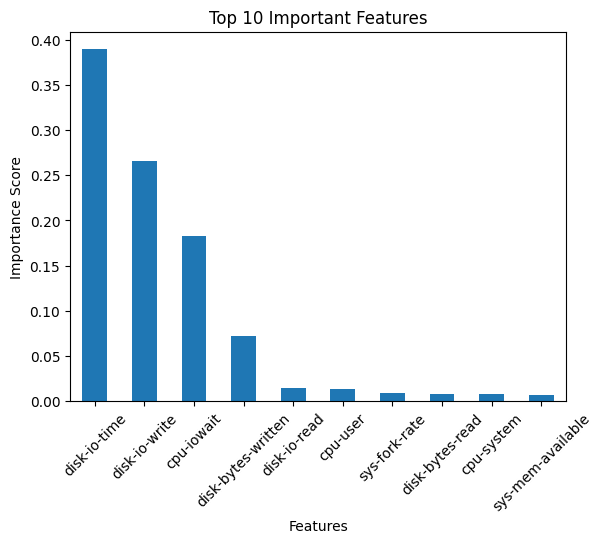

In [22]:
import matplotlib.pyplot as plt

fi.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.show()

In [23]:
from sklearn.model_selection import cross_val_score

# 5-fold cross validation
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.99959493 0.99994213 0.99994213 0.99982639 0.99971065]
Mean accuracy: 0.999803245429041


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Results
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.97882067010011
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     16822
           1       0.83      0.26      0.39       459

    accuracy                           0.98     17281
   macro avg       0.90      0.63      0.69     17281
weighted avg       0.98      0.98      0.97     17281



In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.999710664892078
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16822
           1       0.99      1.00      0.99       459

    accuracy                           1.00     17281
   macro avg       1.00      1.00      1.00     17281
weighted avg       1.00      1.00      1.00     17281



In [26]:
# Save feature means (baseline normal behavior)
feature_means = X.mean()

import joblib
joblib.dump(feature_means, "feature_means.pkl")

['feature_means.pkl']

In [27]:
import joblib

# Save trained model
joblib.dump(model, "bottleneck_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [34]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib

# Load model and feature baseline
model = joblib.load("bottleneck_model.pkl")
feature_means = joblib.load("feature_means.pkl")

st.title("IT System Bottlenecks on Server and Network Performance Logs")
st.write("Simulated real-time monitoring using ML")

# User-controlled sliders
cpu_user = st.slider("CPU User Usage", 0.0, 1.0, 0.3)
cpu_iowait = st.slider("CPU IO Wait", 0.0, 1.0, 0.1)
disk_io_time = st.slider("Disk IO Time", 0.0, 1.0, 0.02)

# Create full input with baseline values
input_df = pd.DataFrame([feature_means])

# Override key metrics
input_df["cpu-user"] = cpu_user
input_df["cpu-iowait"] = cpu_iowait
input_df["disk-io-time"] = disk_io_time

# Predict bottleneck risk
if st.button("Predict Bottleneck Risk"):
    prob = model.predict_proba(input_df)[0][1]   # Probability of bottleneck
    risk_percent = round(prob * 100, 2)

    # Risk interpretation
    if risk_percent < 30:
        st.success(f"✅ LOW RISK: {risk_percent}%")
    elif risk_percent < 70:
        st.warning(f"⚠️ MEDIUM RISK: {risk_percent}%")
    else:
        st.error(f"🚨 HIGH RISK: {risk_percent}%")

        # -------- ALERT & RECOMMENDATION SYSTEM --------

    st.subheader("Bottleneck Analysis")

    causes = []
    actions = []

    if cpu_user > 0.7:
        causes.append("High CPU User Usage")
        actions.append("Reduce running processes or scale CPU resources")

    if cpu_iowait > 0.3:
        causes.append("High CPU IO Wait")
        actions.append("Check disk performance or optimize I/O operations")

    if disk_io_time > 0.02:
        causes.append("High Disk IO Time")
        actions.append("Increase disk IOPS or postpone heavy disk tasks")

    if causes:
        st.error("Bottleneck Causes Detected:")
        for c in causes:
            st.write("•", c)

        st.info("🛠 Recommended Actions:")
        for a in actions:
            st.write("•", a)
    else:
        st.success(" No critical bottleneck causes identified")

Writing app.py


In [35]:
import os

print(os.listdir())

['.config', '.ipynb_checkpoints', 'feature_means.pkl', 'bottleneck_model.pkl', 'app.py', 'drive', 'sample_data']


In [44]:
from google.colab import files

files.download("app.py")
files.download("feature_means.pkl")
files.download("bottleneck_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>